# Import Libraries

In [1]:
# Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

# Loading CAR Data

In [2]:
# data path (NOTE: CHANGE THIS DEPENDING ON THE PARTICULAR PATH WHERE YOU STORE THE CAR DATA)
data_path = "/Users/willkrew/Desktop/Classes/STAT_390/Data/"

folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [3]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [4]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

# Checking the datatype of all the columns
df_main.dtypes


# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Filtering data for relevant rows / time difference columns

In [30]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous menu and seconds to next menu within each Contact Session ID) ---

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# a) Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)
# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column


# Defining new columns

- Reached_queue: caller reaches a queue
- Reached_dead_end: caller reaches a dead end (i.e. a submenu / prompt that refers them to a non Legal aid source)
- Call_successful: caller reaches some desired destination (either a queue or dead end)
- Num_visits: number of times a caller visits a particular menu (in this case LegalMenu2)
- After_first_LegalMenu2_activity: The menu (if any) visited directly after the first visit to LegalMenu2
- After_second_LegalMenu2_activity: The menu (if any) visited directly after the second visit to LegalMenu2
- After_final_LegalMenu2_activity: The menu (if any) visited directly after the final visit to LegalMenu2
- First_LegalMenu2_seconds_until_next: The time (seconds) spent during the first visit to LegalMenu2

In [41]:
import pandas as pd

g = df_filt.groupby('Contact Session ID')

# 1) REACHED QUEUE (old Call_successful logic)
queue_hit = df_filt['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
queue_present = df_filt['Queue Name'].notna()

df_filt['Reached_queue'] = (
    (queue_hit | queue_present)
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 2) REACHED DEAD-END MENUS (corrected names)
dead_end_names = {
    'ChildSupportMenu',
    'WorkersCompMenu',
    'ImmigrationOtherMenu',
    'OtherLegalCriminalCaseMenu',
    'OtherLegalPersonalInjuryMenu',
    'OtherLegalOtherMenu',
}

dead_end_mask = df_filt['Activity Name'].isin(dead_end_names)

df_filt['Reached_dead_end'] = (
    dead_end_mask
      .groupby(df_filt['Contact Session ID'])
      .transform('any')
      .astype(int)
)

# 3) NEW Call_successful = Reached_queue OR Reached_dead_end
df_filt['Call_successful'] = (
    (df_filt['Reached_queue'].eq(1) | df_filt['Reached_dead_end'].eq(1))
    .astype(int)
)

# 4) Num_visits: count of rows with Activity Name exactly 'LegalMenu2'
legal_mask = df_filt['Activity Name'].eq('LegalMenu2')
df_filt['Num_visits'] = (
    legal_mask.groupby(df_filt['Contact Session ID'])
              .transform('sum')
)

# 5) Helper: next Activity Name within session (row-wise shift)
df_filt['_next_activity_in_session'] = g['Activity Name'].shift(-1)

# 6) FIRST LegalMenu2 row per session
cum_legal = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
first_legal_mask = legal_mask & (cum_legal == 1)

first_legal_next_activity_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_first_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(first_legal_next_activity_by_session)

first_legal_wait_by_session = (
    df_filt.loc[first_legal_mask, ['Contact Session ID', 'seconds_until_next']]
          .drop_duplicates('Contact Session ID')
          .set_index('Contact Session ID')['seconds_until_next']
)
df_filt['First_LegalMenu2_seconds_until_next'] = df_filt['Contact Session ID'].map(first_legal_wait_by_session)

# 7) SECOND and FINAL LegalMenu2 logic
legal_ord = legal_mask.groupby(df_filt['Contact Session ID']).cumsum()
legal_total = legal_mask.groupby(df_filt['Contact Session ID']).transform('sum')

second_legal_mask = legal_mask & (legal_ord == 2)
final_legal_mask  = legal_mask & (legal_ord == legal_total) & (legal_total > 0)

second_next_by_session = (
    df_filt.loc[second_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
      .drop_duplicates('Contact Session ID')
      .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_second_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(second_next_by_session)

final_next_by_session = (
    df_filt.loc[final_legal_mask, ['Contact Session ID', '_next_activity_in_session']]
      .drop_duplicates('Contact Session ID')
      .set_index('Contact Session ID')['_next_activity_in_session']
)
df_filt['After_final_LegalMenu2_activity'] = df_filt['Contact Session ID'].map(final_next_by_session)

# 8) clean helper
df_filt.drop(columns=['_next_activity_in_session'], inplace=True)


# Counts of submenu visited after final visit to Legal Menu by each submenu visited first

- Among callers who revisited the legal menu
- Also including the percent of successful calls and reaching a queue for aech submenu visited after a final Legal Menu visit
- To clarify, there is a count and percent success graph for each submenu visited first

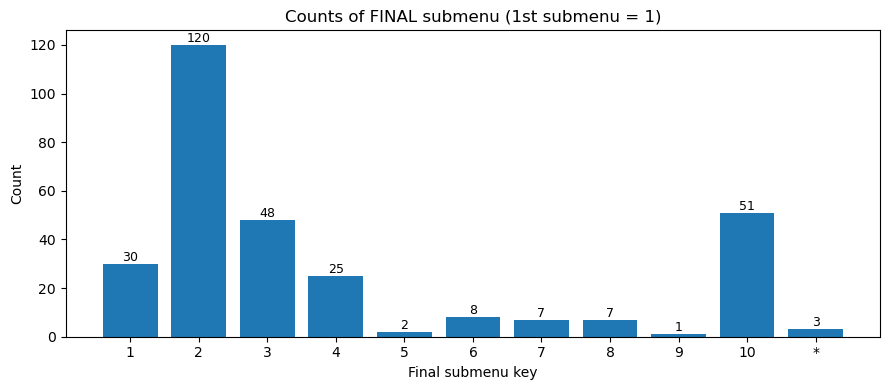

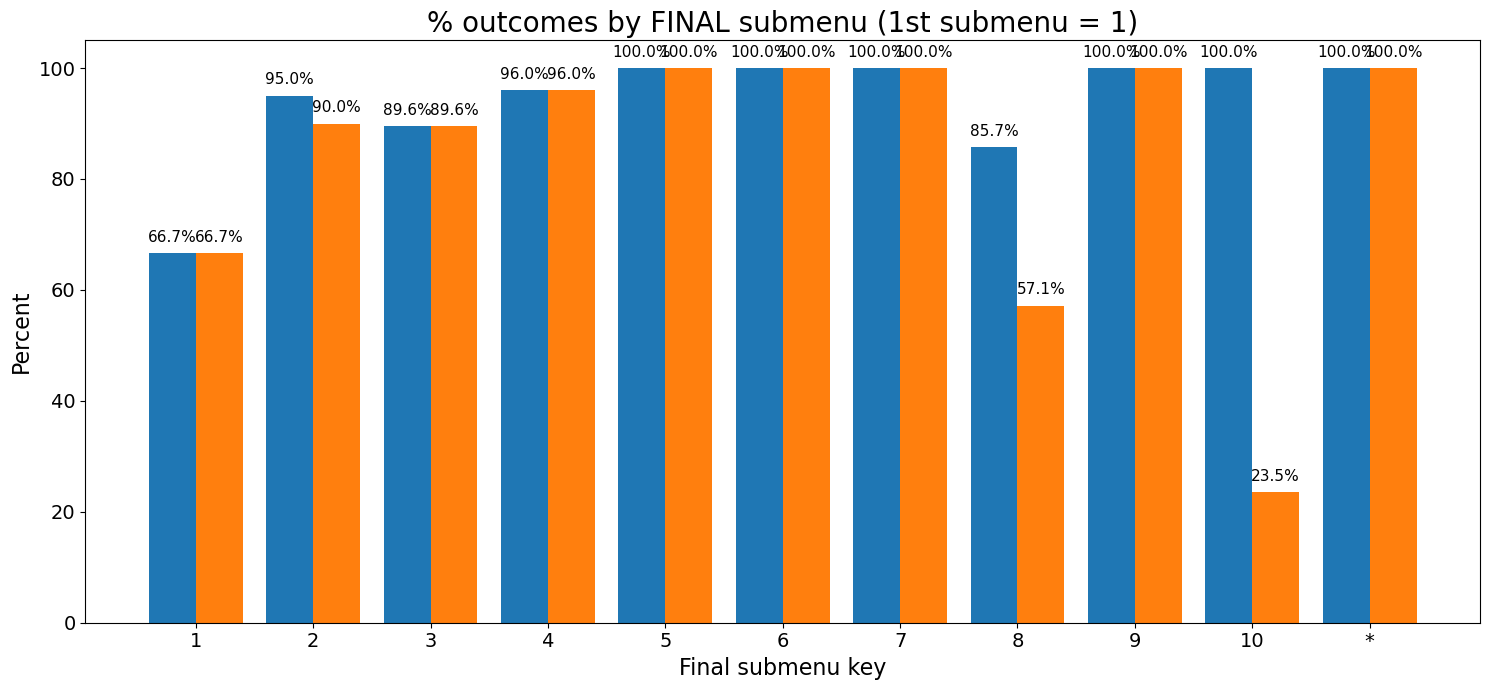

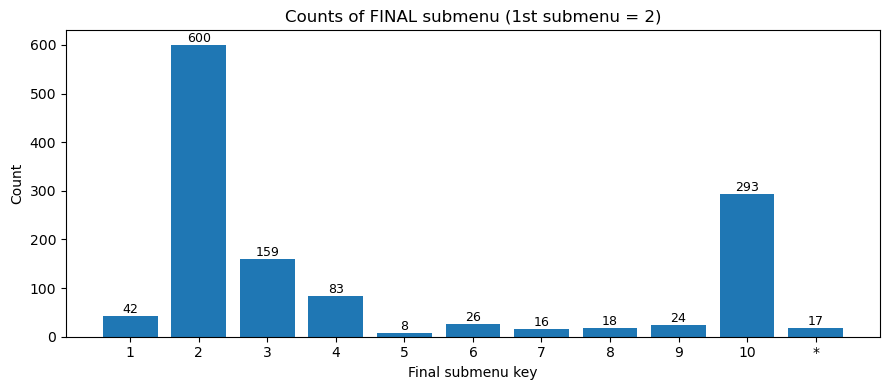

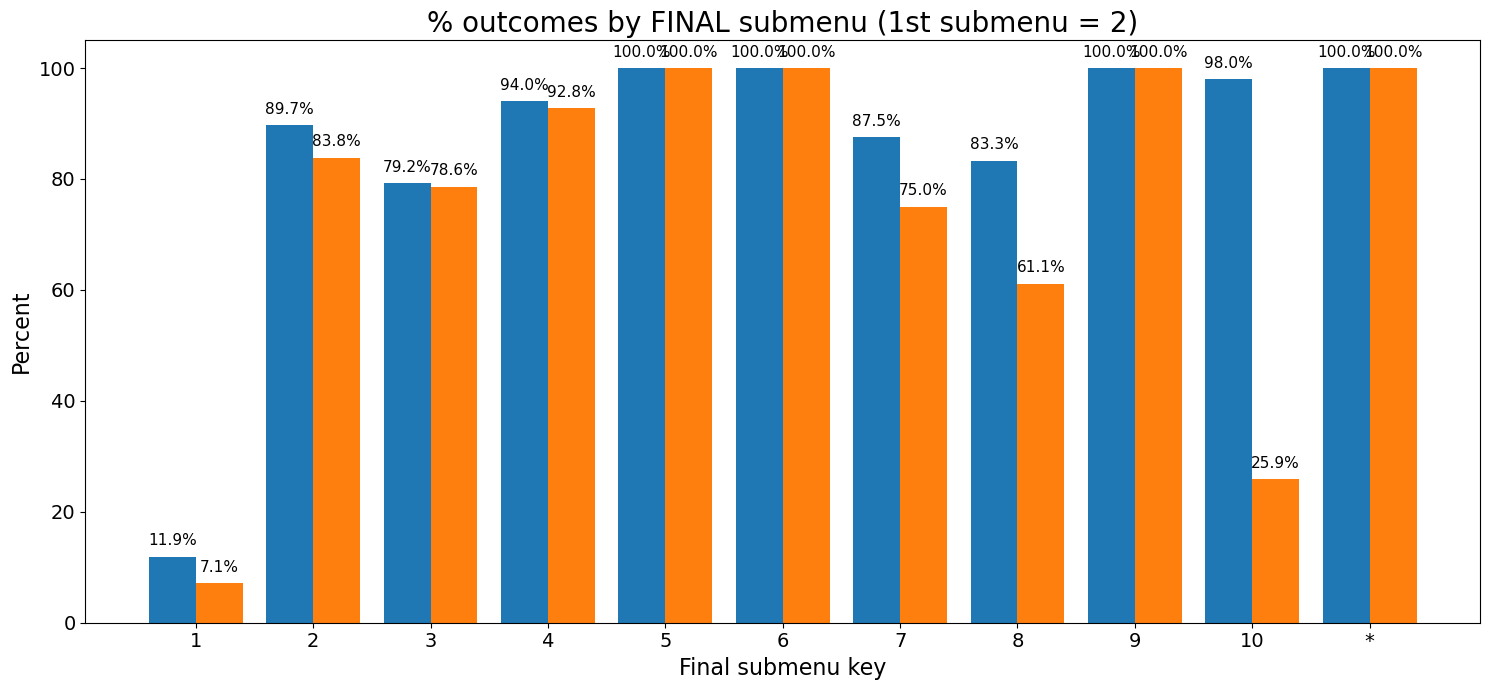

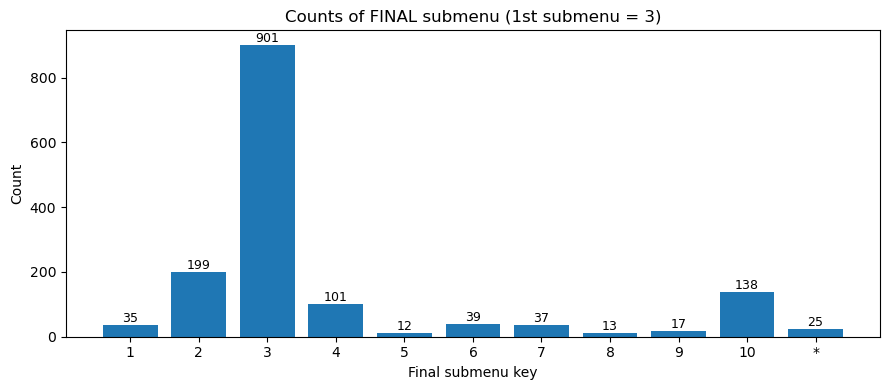

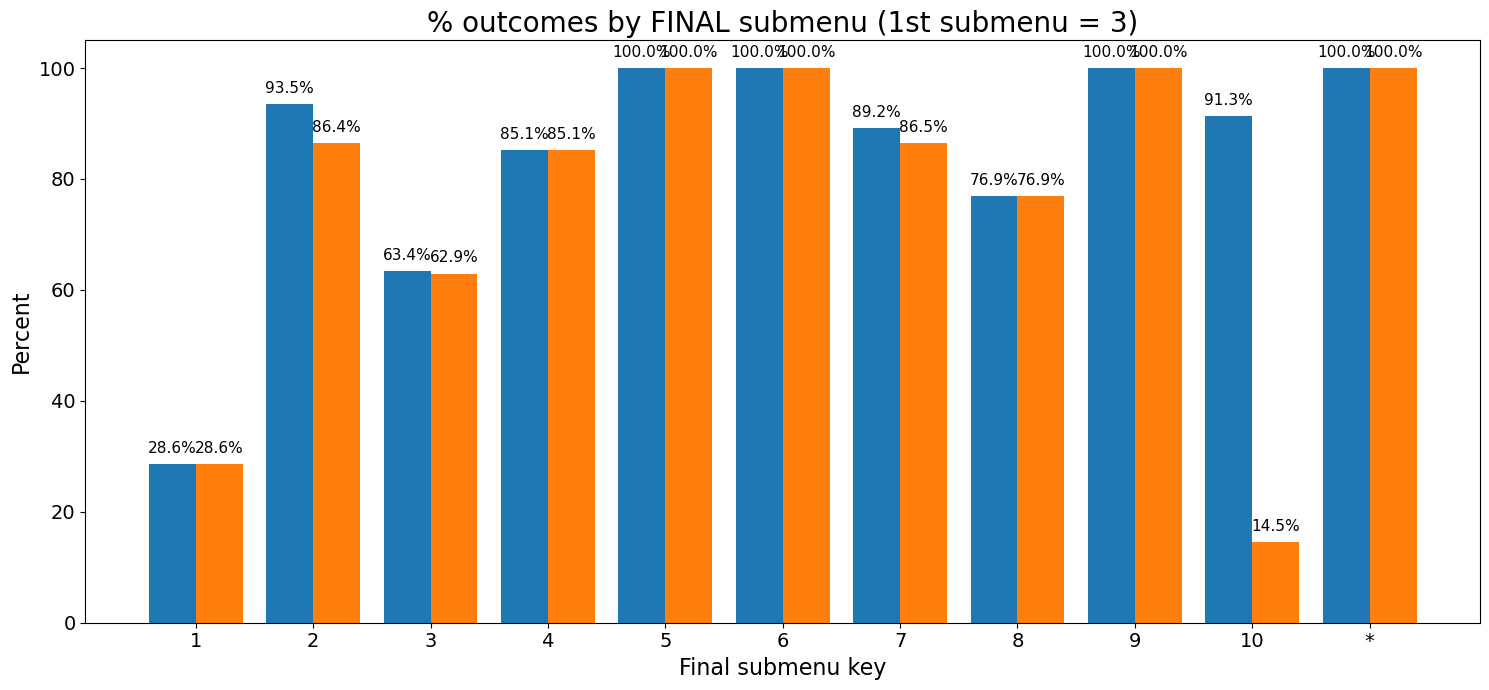

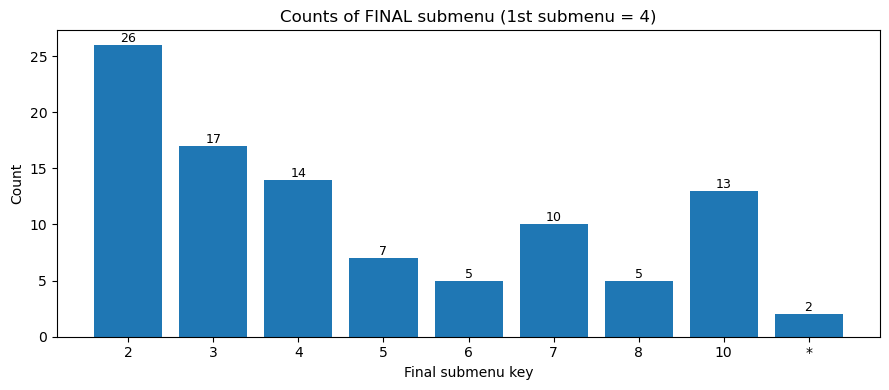

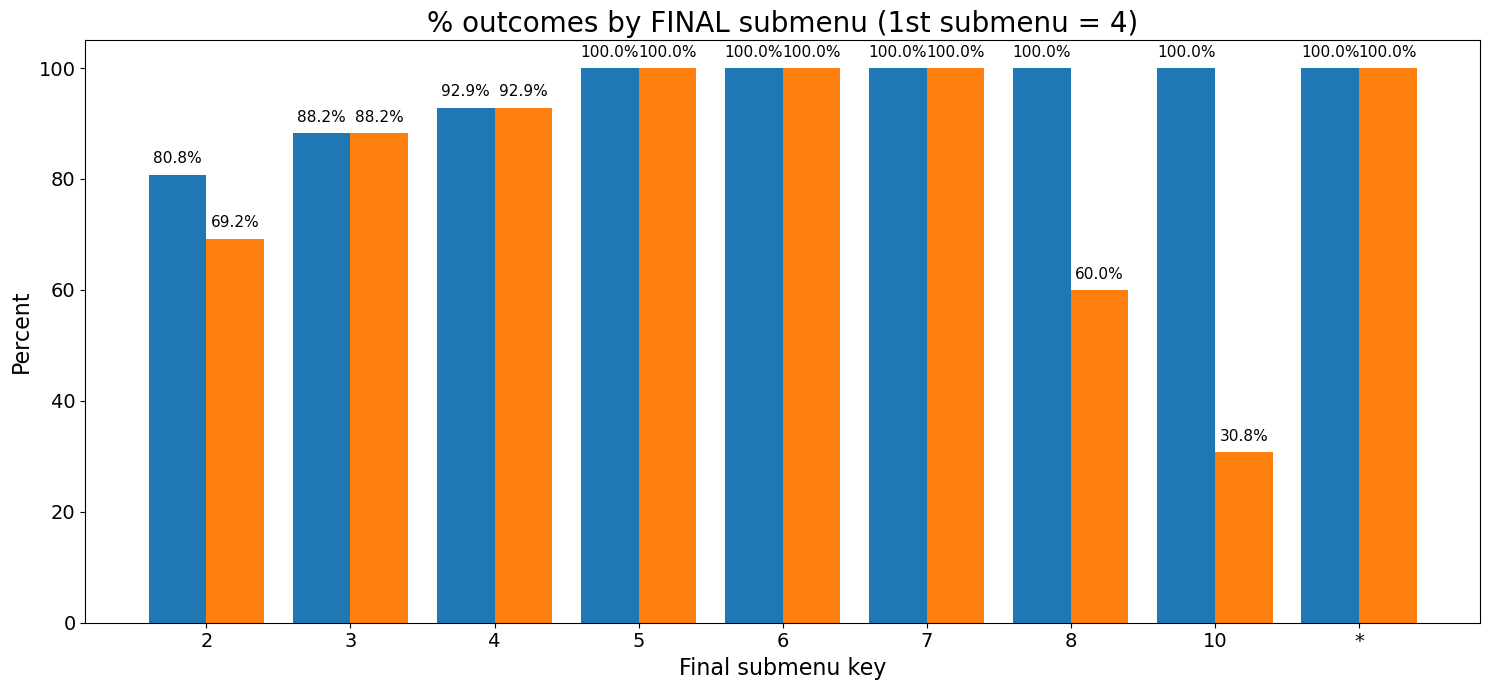

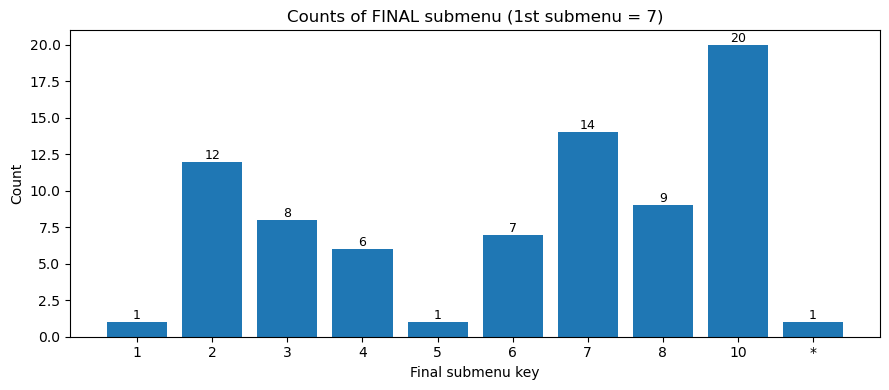

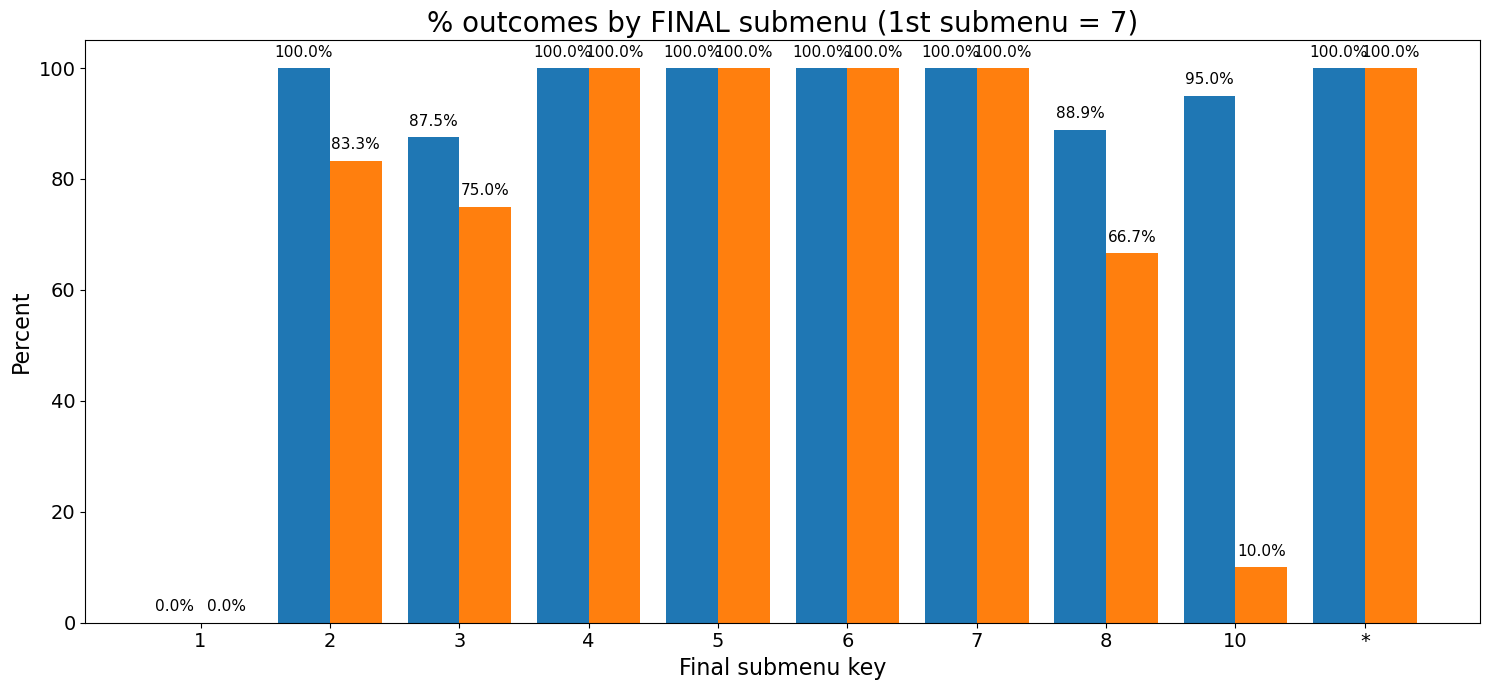

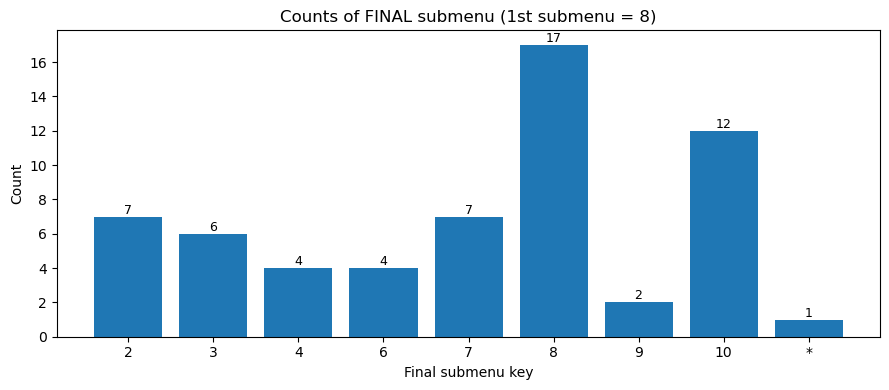

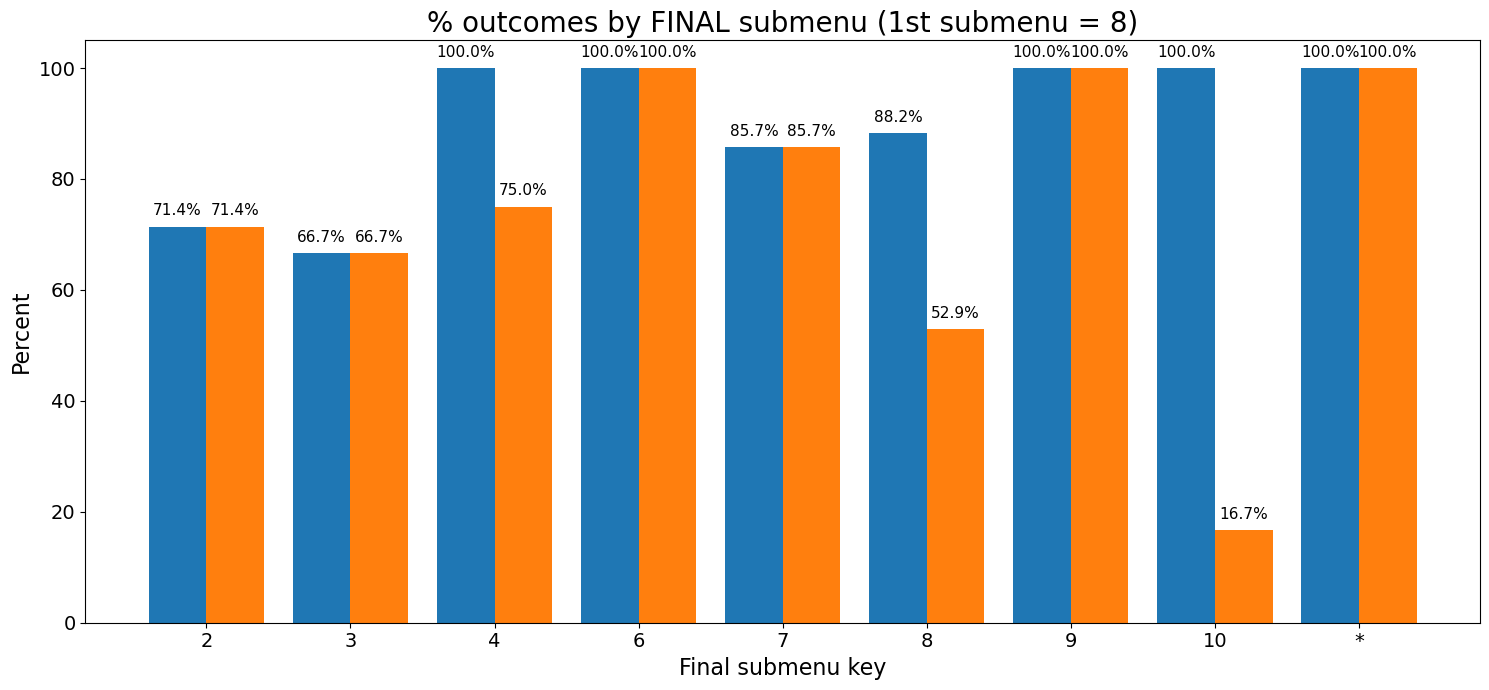

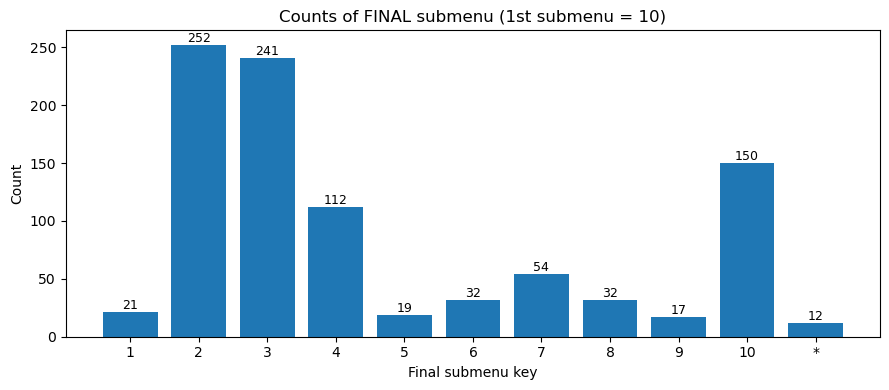

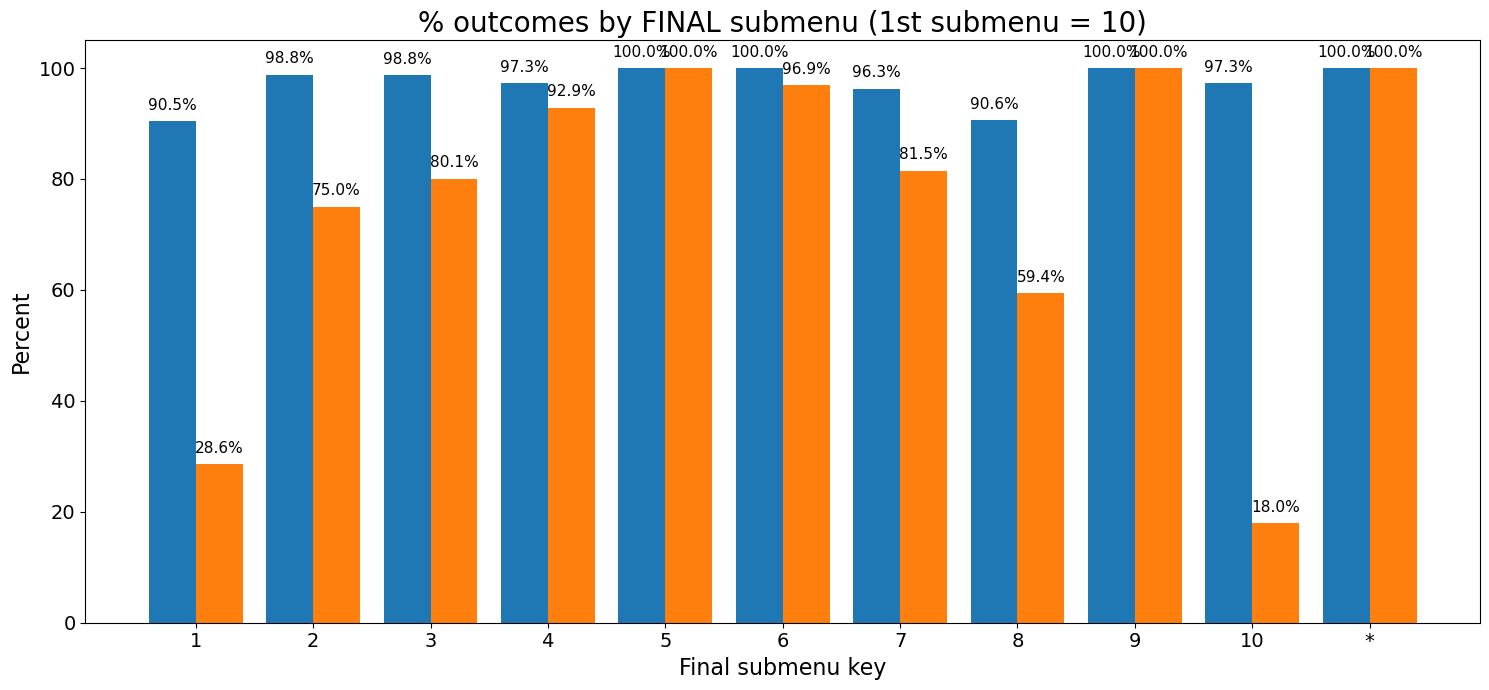

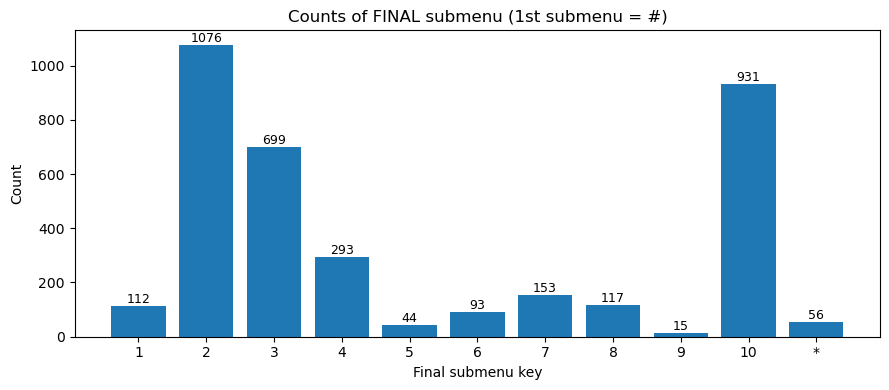

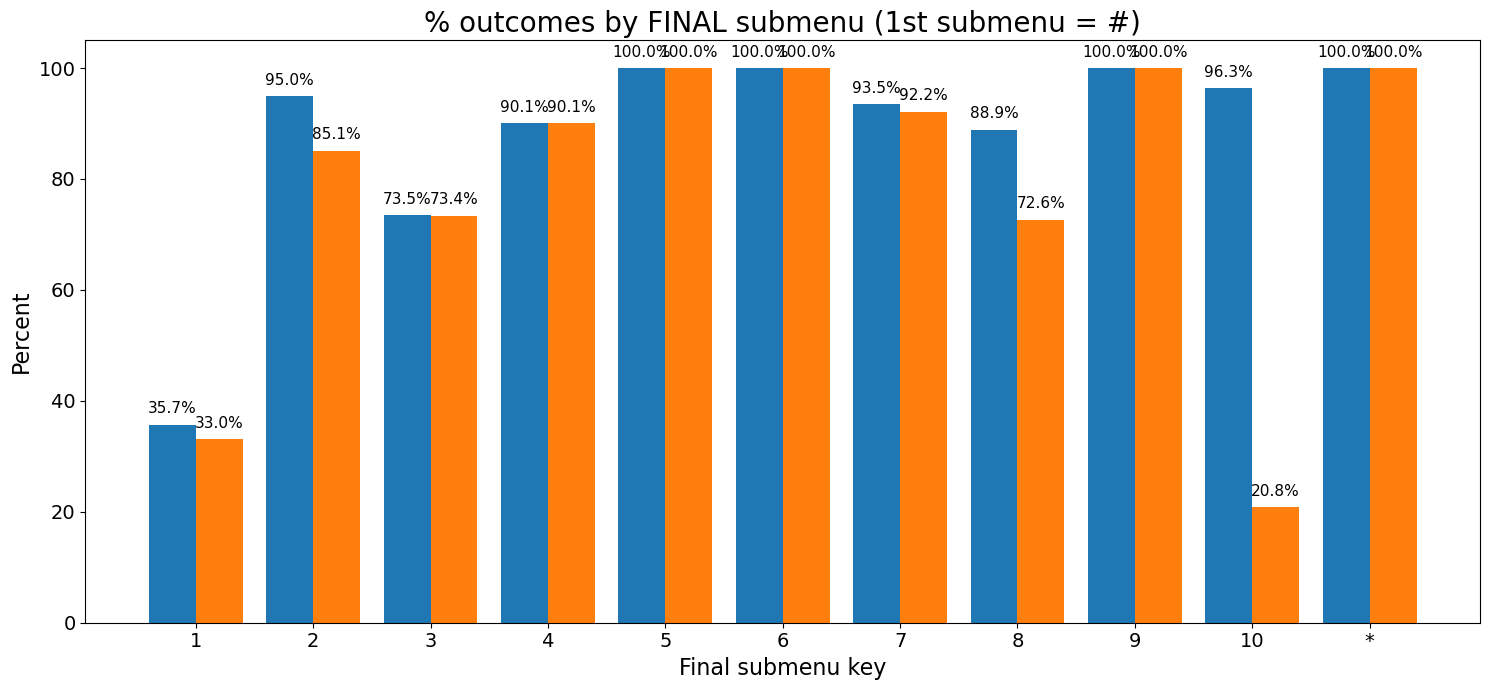

In [56]:
key_to_submenus = {
    '1':  'HIVMenu',
    '2':  'FamilyMenu',
    '3':  'HousingMenu',
    '4':  'BenefitsMenu',
    '5':  'GetLoggedInConsumerAgents | GetLoggedInConsumerSPAgents',
    '6':  'CriminalRecordsVoicemailTransfer',
    '7':  'EmploymentMenu',
    '8':  'ImmigrationMenu',
    '9':  'GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents',
    '10': 'OtherLegalMenu',
    '#':  'LegalMenu2',
    '*':  'FrontDeskTransfer | HolidayPrompt',
    'NoNextMenu': '—',
    'Unknown':    '—',
}

def activity_to_key(activity: object) -> str:
    if pd.isna(activity): return 'NoNextMenu'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

# 1) one row per session
session_df = (
    df_filt[['Contact Session ID',
             'After_first_LegalMenu2_activity',
             'After_final_LegalMenu2_activity',
             'Call_successful',
             'Reached_queue',
             'Num_visits']]
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

# 2) keep ONLY sessions that revisited the legal menu
session_df = session_df[session_df['Num_visits'] > 1].copy()

session_df['After_first_key'] = session_df['After_first_LegalMenu2_activity'].map(activity_to_key)
session_df['After_final_key'] = session_df['After_final_LegalMenu2_activity'].map(activity_to_key)

# only sessions that actually have a final submenu
session_df = session_df[
    session_df['After_final_key'].notna()
    & (session_df['After_final_key'] != 'NoNextMenu')
    & (session_df['After_final_key'] != 'Unknown')
].copy()

x_order = ['1','2','3','4','5','6','7','8','9','10','#','*']
first_keys = ['1','2','3','4','5','6','7','8','9','10','#','*']

for k in first_keys:
    sub = session_df[session_df['After_first_key'] == k]
    if sub.empty:
        continue

    # --- Plot 1: counts of FINAL submenu ---
    counts = (
        sub['After_final_key']
        .value_counts()
        .reindex(x_order)
        .fillna(0)
        .astype(int)
    )
    mask = counts > 0
    plot_keys   = counts.index[mask]
    plot_counts = counts[mask]

    plt.figure(figsize=(9, 4))
    bars = plt.bar(range(len(plot_counts)), plot_counts.values)
    plt.title(f"Counts of FINAL submenu (1st submenu = {k})")
    plt.xlabel("Final submenu key")
    plt.ylabel("Count")
    plt.xticks(range(len(plot_counts)), plot_keys, ha='center', rotation=0)
    for r, v in zip(bars, plot_counts.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(),
                 f"{int(v)}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: % Call_successful vs % Reached_queue (wide, no legend) ---
    grp = sub.groupby('After_final_key')
    pct_success = (grp['Call_successful'].mean() * 100).reindex(x_order)
    pct_queue   = (grp['Reached_queue'].mean()   * 100).reindex(x_order)
    
    pct_success = pct_success[mask]
    pct_queue   = pct_queue[mask]
    
    x = np.arange(len(plot_keys))
    bar_width = 0.4
    
    fig, ax = plt.subplots(figsize=(15, 7))
    b1 = ax.bar(x - bar_width/2, pct_success.values, bar_width, color='C0')
    b2 = ax.bar(x + bar_width/2, pct_queue.values,   bar_width, color='C1')
    
    ax.set_title(f"% outcomes by FINAL submenu (1st submenu = {k})", fontsize=20)
    ax.set_xlabel("Final submenu key", fontsize=16)
    ax.set_ylabel("Percent", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_keys, ha='center', rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    max_pct = max(pct_success.max(), pct_queue.max())
    ax.set_ylim(0, min(105, max_pct + 5))
    
    # labels ABOVE bars, black
    for r, v in zip(b1, pct_success.values):
        ax.text(
            r.get_x() + r.get_width()/2,
            r.get_height() + 1.5,     # a little above the bar
            f"{v:.1f}%",
            ha='center',
            va='bottom',
            fontsize=11,
            color='black'
        )
    
    for r, v in zip(b2, pct_queue.values):
        ax.text(
            r.get_x() + r.get_width()/2,
            r.get_height() + 1.5,
            f"{v:.1f}%",
            ha='center',
            va='bottom',
            fontsize=11,
            color='black'
        )
    
    fig.tight_layout()
    plt.show()



# Counts of submenu visited after second visit to Legal Menu by each submenu visited first

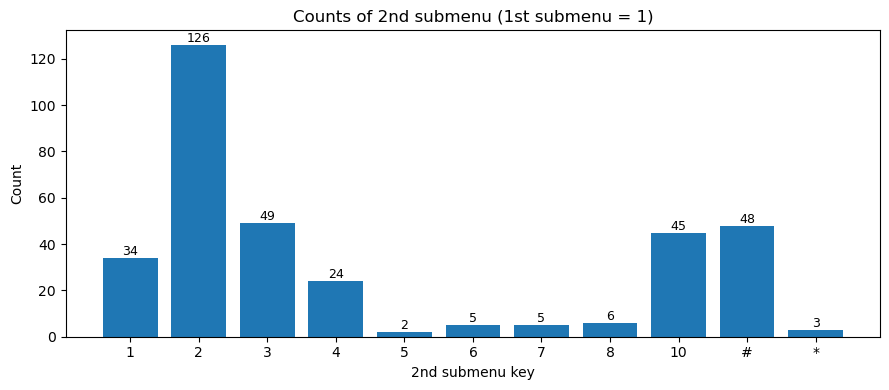

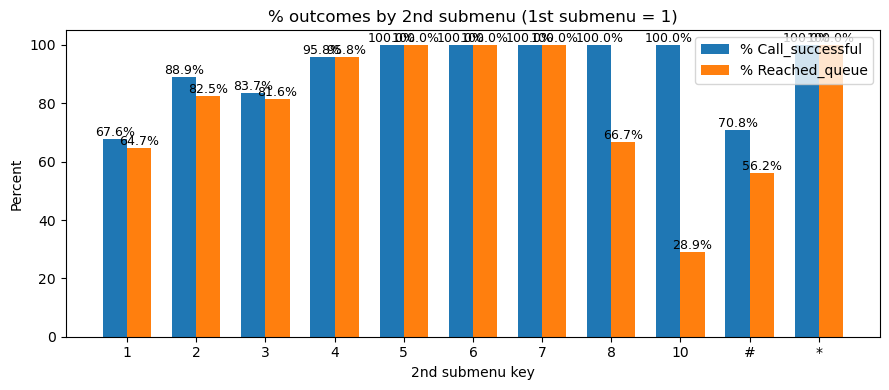

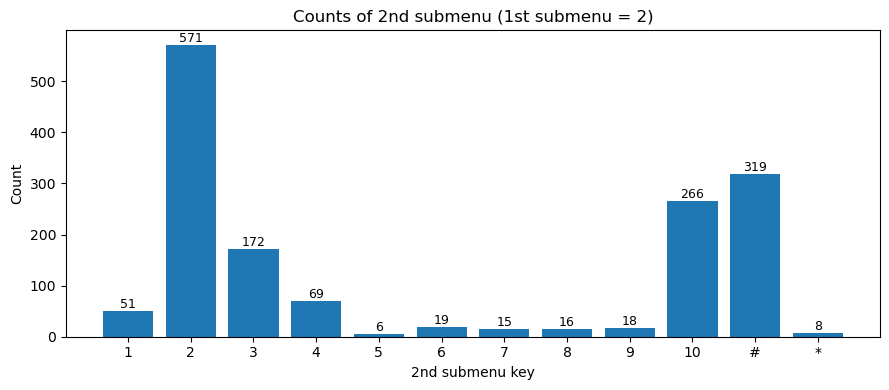

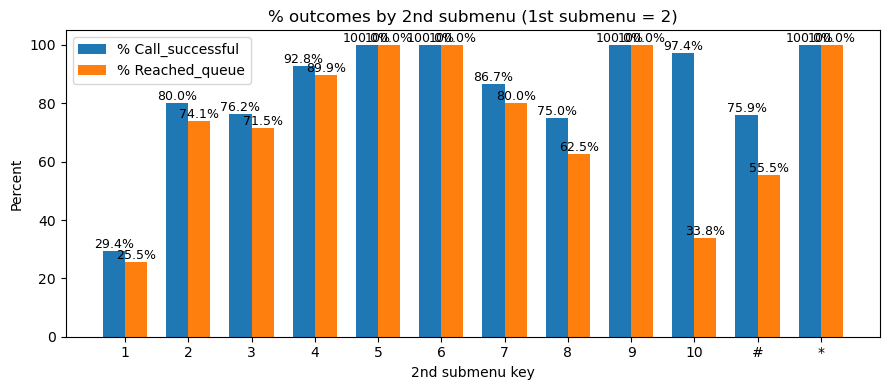

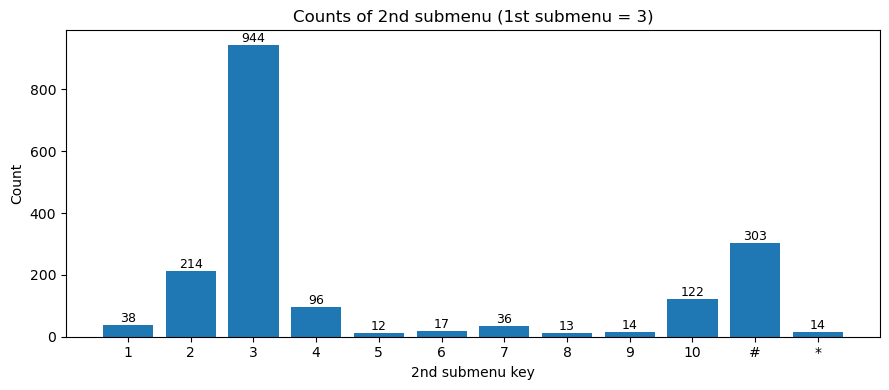

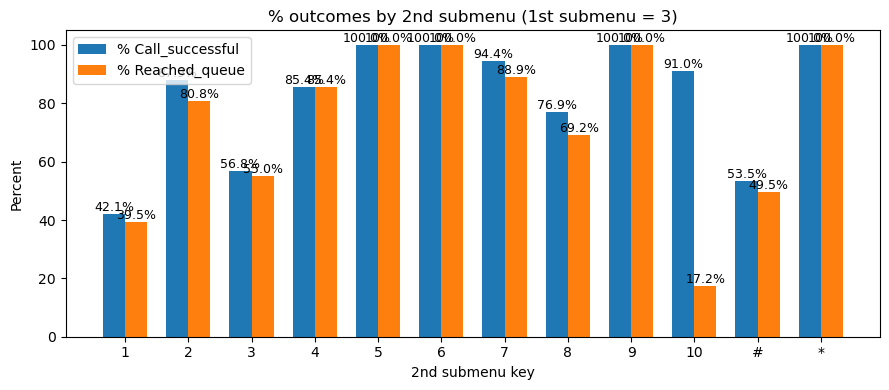

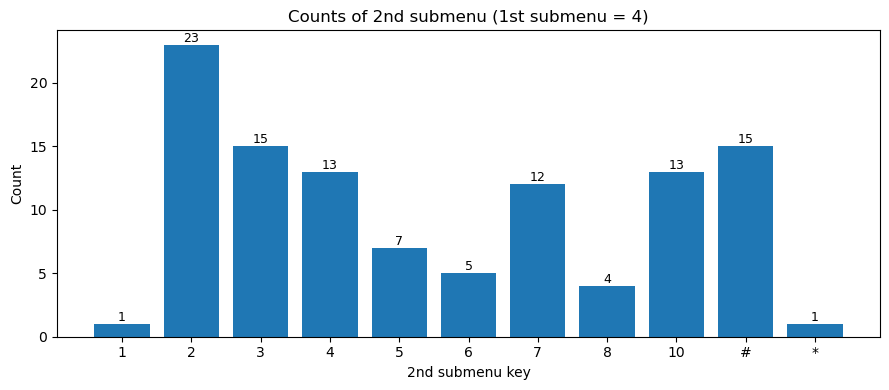

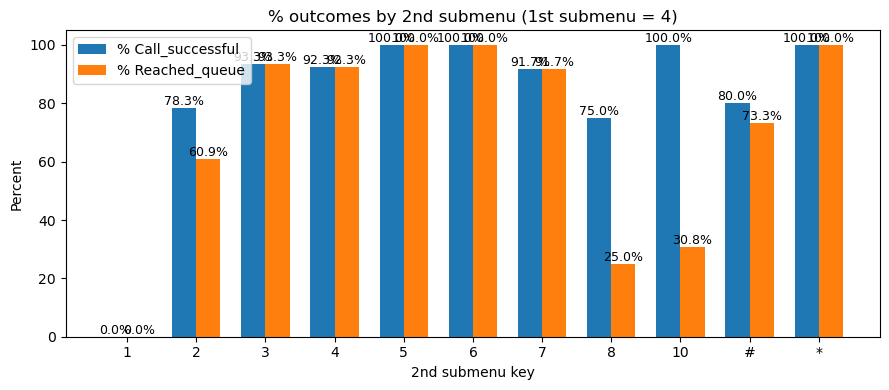

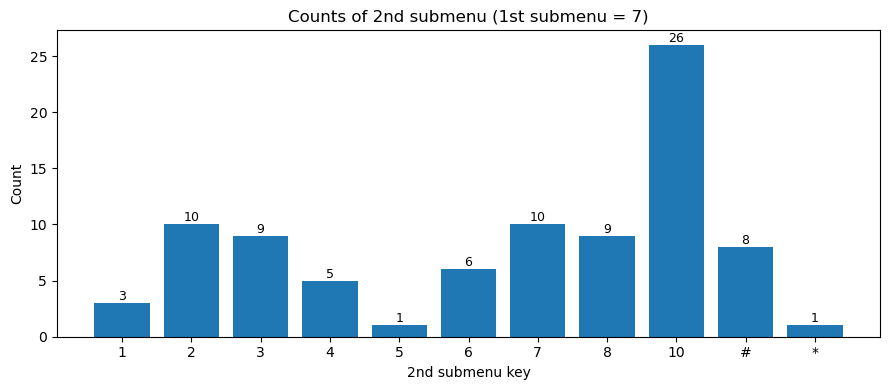

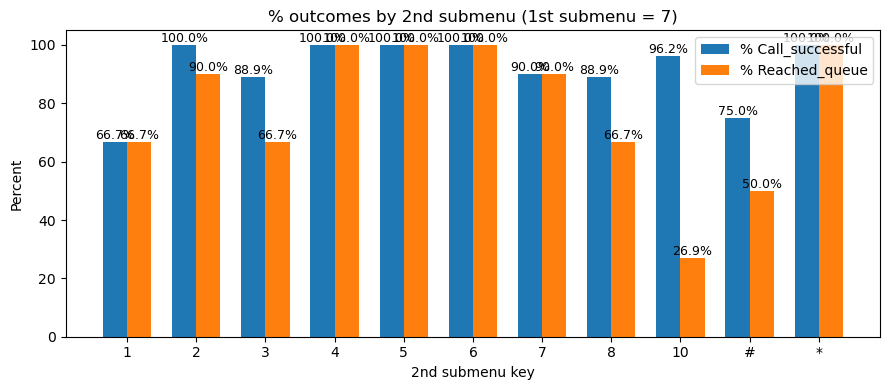

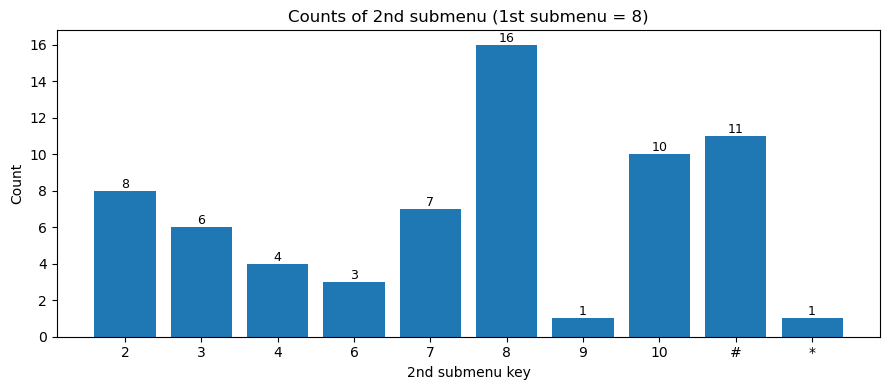

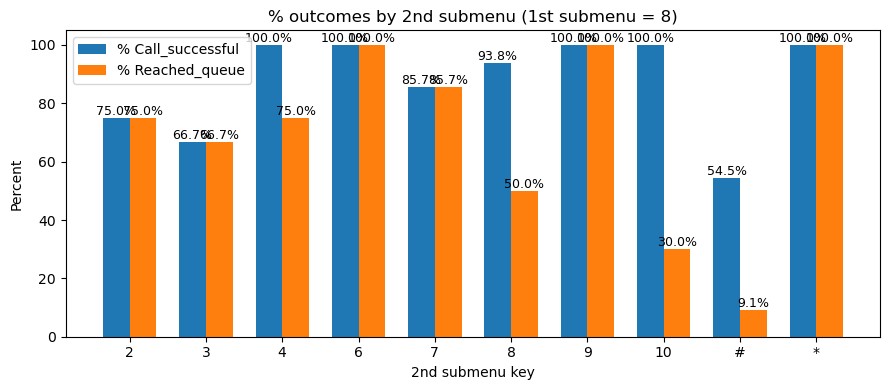

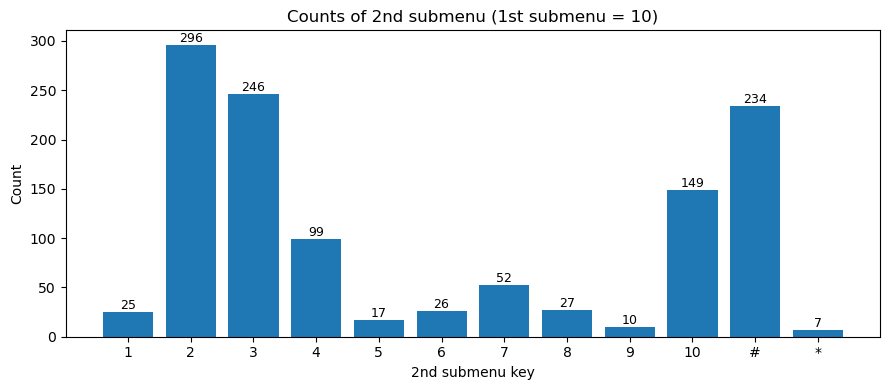

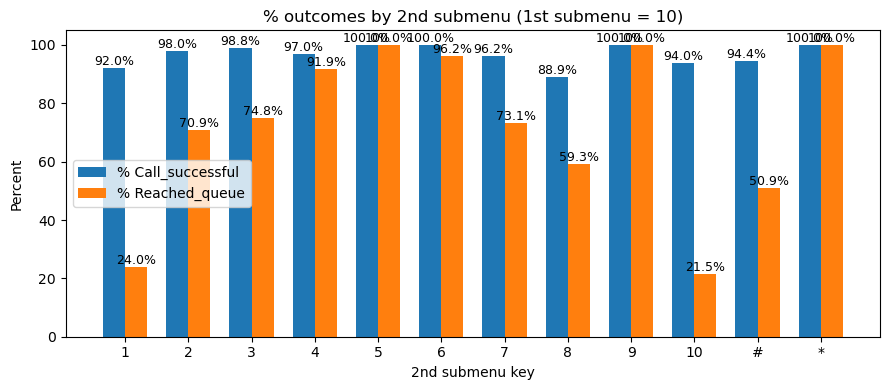

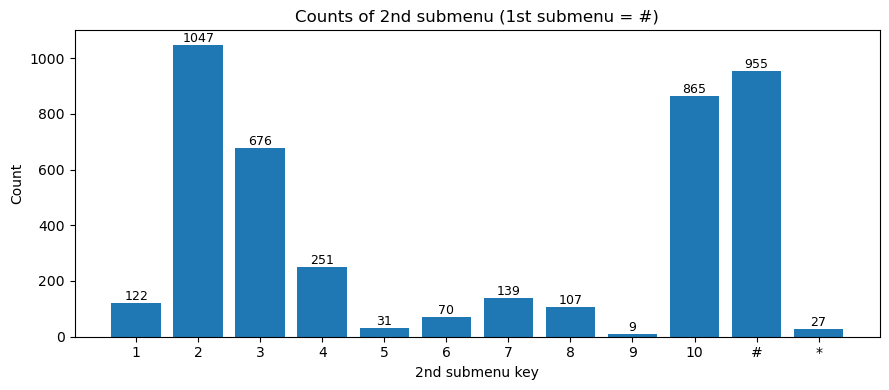

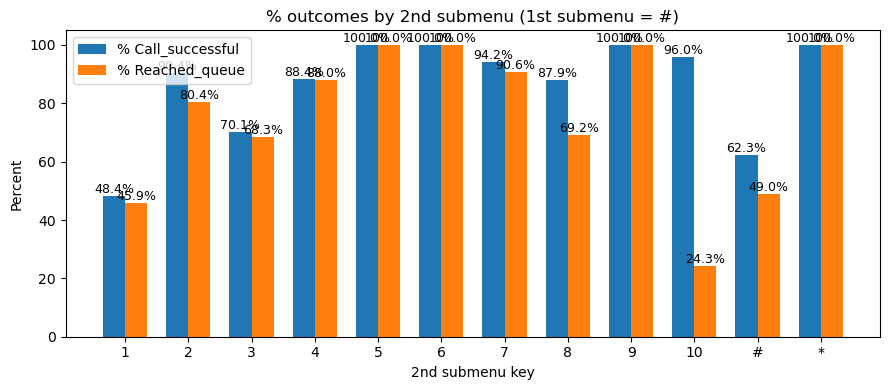

In [46]:
# --- mapping from key -> submenu(s) (for ordering/name reference if needed) ---
key_to_submenus = {
    '1':  'HIVMenu',
    '2':  'FamilyMenu',
    '3':  'HousingMenu',
    '4':  'BenefitsMenu',
    '5':  'GetLoggedInConsumerAgents | GetLoggedInConsumerSPAgents',
    '6':  'CriminalRecordsVoicemailTransfer',
    '7':  'EmploymentMenu',
    '8':  'ImmigrationMenu',
    '9':  'GetLoggedInADAPTAgents | GetLoggedInADAPTSPAgents',
    '10': 'OtherLegalMenu',
    '#':  'LegalMenu2',
    '*':  'FrontDeskTransfer | HolidayPrompt',
    'NoNextMenu': '—',
    'Unknown':    '—',
}

# same activity -> key function you’ve been using
def activity_to_key(activity: object) -> str:
    if pd.isna(activity): return 'NoNextMenu'
    s = str(activity).strip().lower()
    if s == 'hivmenu': return '1'
    if s == 'familymenu': return '2'
    if s == 'housingmenu': return '3'
    if s == 'benefitsmenu': return '4'
    if s in ('getloggedinconsumeragents', 'getloggedinconsumerspagents'): return '5'
    if s == 'criminalrecordsvoicemailtransfer': return '6'
    if s == 'employmentmenu': return '7'
    if s == 'immigrationmenu': return '8'
    if s in ('getloggedinadaptagents', 'getloggedinadaptspagents'): return '9'
    if s == 'otherlegalmenu': return '10'
    if s == 'legalmenu2': return '#'
    if s in ('frontdesktransfer', 'holidayprompt'): return '*'
    return 'Unknown'

# --- 1) Collapse to one row per Contact Session ID with the fields we need ---
session_df = (
    df_filt[['Contact Session ID',
             'After_first_LegalMenu2_activity',
             'After_second_LegalMenu2_activity',
             'Call_successful',   # new definition: queue OR dead-end
             'Reached_queue']]    # queue only
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

session_df['After_first_key']  = session_df['After_first_LegalMenu2_activity'].map(activity_to_key)
session_df['After_second_key'] = session_df['After_second_LegalMenu2_activity'].map(activity_to_key)

# only look at sessions that actually chose something after the 2nd legal menu
session_df = session_df[
    session_df['After_second_key'].notna()
    & (session_df['After_second_key'] != 'NoNextMenu')
    & (session_df['After_second_key'] != 'Unknown')
].copy()

# fixed order for x-axis
x_order = ['1','2','3','4','5','6','7','8','9','10','#','*']

# first submenus we care about
first_keys = ['1','2','3','4','5','6','7','8','9','10','#','*']

for k in first_keys:
    sub = session_df[session_df['After_first_key'] == k]
    if sub.empty:
        continue

    # ---------- Plot 1: counts of second submenu ----------
    counts = (
        sub['After_second_key']
        .value_counts()
        .reindex(x_order)
        .fillna(0)
        .astype(int)
    )
    # only nonzero ones
    mask = counts > 0
    plot_keys   = counts.index[mask]
    plot_counts = counts[mask]

    plt.figure(figsize=(9, 4))
    bars = plt.bar(range(len(plot_counts)), plot_counts.values)
    plt.title(f"Counts of 2nd submenu (1st submenu = {k})")
    plt.xlabel("2nd submenu key")
    plt.ylabel("Count")
    plt.xticks(range(len(plot_counts)), plot_keys, ha='center', rotation=0)
    for r, v in zip(bars, plot_counts.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(v)}",
                 ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

  # ---------- Plot 2: % Call_successful vs % Reached_queue ----------
    grp = sub.groupby('After_second_key')
    pct_success = (grp['Call_successful'].mean() * 100).reindex(x_order)
    pct_queue   = (grp['Reached_queue'].mean() * 100).reindex(x_order)
    
    pct_success = pct_success[mask]
    pct_queue   = pct_queue[mask]
    
    x = np.arange(len(plot_keys))
    width = 0.35
    
    plt.figure(figsize=(9, 4))
    b1 = plt.bar(x - width/2, pct_success.values, width, label='% Call_successful')
    b2 = plt.bar(x + width/2, pct_queue.values,   width, label='% Reached_queue')
    
    plt.title(f"% outcomes by 2nd submenu (1st submenu = {k})")
    plt.xlabel("2nd submenu key")
    plt.ylabel("Percent")
    plt.xticks(x, plot_keys, ha='center', rotation=0)
    
    # give some headroom so 100% labels don't get clipped
    max_pct = max(pct_success.max(), pct_queue.max())
    plt.ylim(0, min(105, max_pct + 5))
    
    plt.legend()
    
    # labels on bars
    for r, v in zip(b1, pct_success.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(),
                 f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
    for r, v in zip(b2, pct_queue.values):
        plt.text(r.get_x() + r.get_width()/2, r.get_height(),
                 f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()


# Percent successful calls by reaching right submenu and listening to full prompt

In [57]:
# collapse to one row per call
session = (
    df_filt[['Contact Session ID',
             'Call_successful',
             'Num_visits',
             'First_LegalMenu2_seconds_until_next']]
    .drop_duplicates(subset='Contact Session ID')
    .copy()
)

# keep only people who actually visited LegalMenu2 at least once
session = session[session['Num_visits'] >= 1].copy()

# heard all options?
session['heard_all'] = np.where(
    session['First_LegalMenu2_seconds_until_next'].notna() &
    (session['First_LegalMenu2_seconds_until_next'] >= 120),
    1, 0
)

# right menu vs revisited
session['revisited'] = np.where(session['Num_visits'] > 1, 1, 0)

# now group into the 4 combos
summary = (
    session
    .groupby(['heard_all', 'revisited'])
    .agg(
        total_calls = ('Contact Session ID', 'count'),
        success_calls = ('Call_successful', 'sum')
    )
    .reset_index()
)

# compute success rate
summary['pct_success'] = (summary['success_calls'] / summary['total_calls']) * 100

# make it nicer to read
mapping_heard = {1: "Heard all options (>=120s)", 0: "Didn't hear all options (<120s or missing)"}
mapping_rev   = {0: "Reached right menu (Num_visits = 1)",
                 1: "Revisited legal menu (Num_visits > 1)"}

summary['heard_all_desc'] = summary['heard_all'].map(mapping_heard)
summary['revisited_desc'] = summary['revisited'].map(mapping_rev)

# final tidy table
final_table = summary[[
    'heard_all_desc',
    'revisited_desc',
    'total_calls',
    'success_calls',
    'pct_success'
]].sort_values(['heard_all_desc', 'revisited_desc'])


In [58]:
final_table

,heard_all_desc,revisited_desc,total_calls,success_calls,pct_success
0,Didn't hear all options (<120s or missing),Reached right menu (Num_visits = 1),61738,49014,79.390327
1,Didn't hear all options (<120s or missing),Revisited legal menu (Num_visits > 1),6851,4312,62.939717
2,Heard all options (>=120s),Reached right menu (Num_visits = 1),18163,15700,86.439465
3,Heard all options (>=120s),Revisited legal menu (Num_visits > 1),5944,4773,80.299462
